# Task 1: Exploratory Data Analysis and Data Preprocessing

In [6]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocess import clean_narrative

sns.set_theme(style='whitegrid')
%matplotlib inline

In [12]:
import re # For Regular Expressions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import nltk

nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Simbo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## 1. Load Dataset

In [43]:
import pandas as pd

RAW_PATH = "../data/raw/complaints.csv"

df_raw = pd.read_csv(
    RAW_PATH,
    nrows=50000,      # prevents MemoryError
    low_memory=True
)

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

Shape: (50000, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


## 2. Exploratory Data Analysis


In [44]:
print('=== Column names ===')
print(df_raw.columns.tolist())
print(f'\n=== Total records: {len(df_raw):,} ===')
print(f'Missing values (%):\n{(df_raw.isnull().mean() * 100).round(1)}')

=== Column names ===
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

=== Total records: 50,000 ===
Missing values (%):
Date received                     0.0
Product                           0.0
Sub-product                       0.0
Issue                             0.0
Sub-issue                         0.9
Consumer complaint narrative     98.7
Company public response          97.3
Company                           0.0
State                             0.1
ZIP code                          0.0
Tags                             97.9
Consumer consent provided?       96.7
Submitted via                     0.0
Date sent to company              0.0
Company response to consumer      0.0
Timely response?                

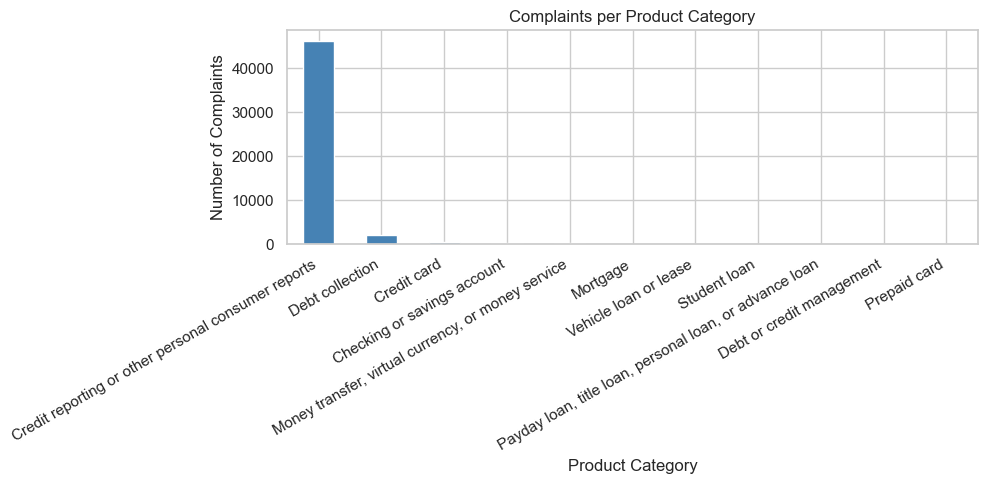

In [45]:
# Distribution of complaints by product category
fig, ax = plt.subplots(figsize=(10, 5))
df_raw['Product'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Product Category')
ax.set_ylabel('Number of Complaints')
ax.set_title('Complaints per Product Category')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/product_distribution.png', dpi=120)
plt.show()

With narrative:      672 (1.3%)
Without narrative:   49,328 (98.7%)


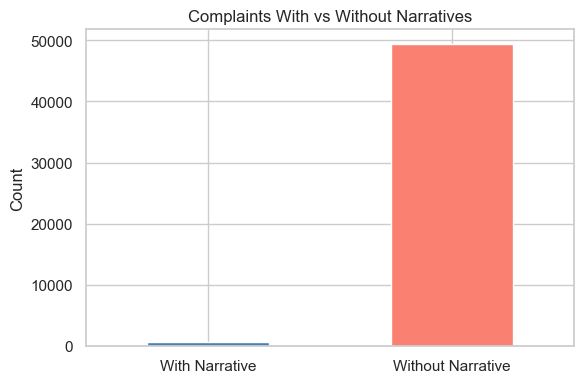

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Correct column name
narrative_col = "Consumer complaint narrative"

has_narrative = (
    df_raw[narrative_col]
    .notna()
    &
    (
        df_raw[narrative_col]
        .astype(str)
        .str.strip()
        != ""
    )
)

print(
    f"With narrative: {has_narrative.sum():>8,} ({has_narrative.mean():.1%})"
)

print(
    f"Without narrative: {(~has_narrative).sum():>8,} ({(~has_narrative).mean():.1%})"
)

fig, ax = plt.subplots(
    figsize=(6, 4)
)

pd.Series({
    "With Narrative":
        has_narrative.sum(),

    "Without Narrative":
        (~has_narrative).sum()
}).plot(
    kind="bar",
    ax=ax,
    color=["steelblue", "salmon"],
    edgecolor="white"
)

ax.set_title(
    "Complaints With vs Without Narratives"
)

ax.set_ylabel(
    "Count"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "../data/processed/narrative_availability.png",
    dpi=120
)

plt.show()

count     672.000000
mean      207.275298
std       171.918924
min         9.000000
25%        91.000000
50%       164.500000
75%       283.000000
max      1741.000000
Name: Consumer complaint narrative, dtype: float64


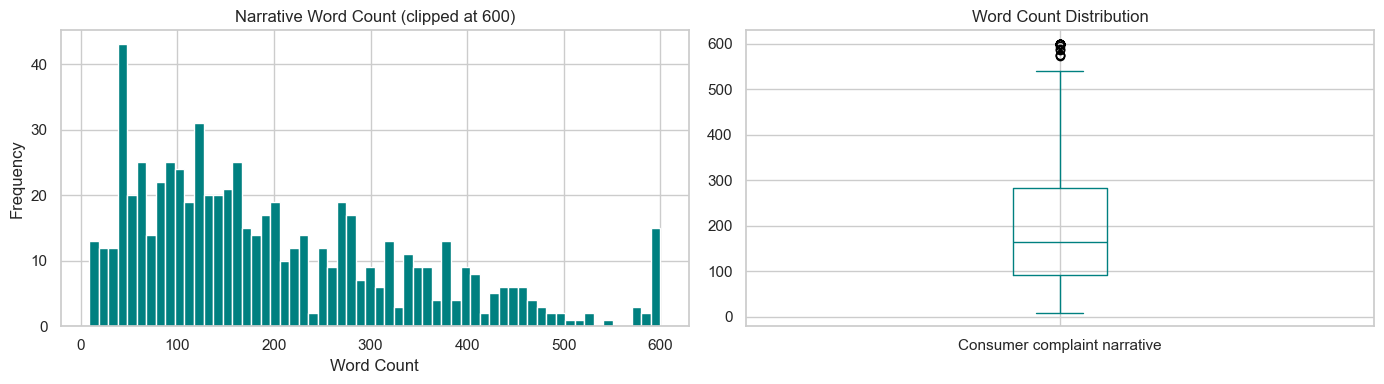

In [47]:
# Narrative word-count distribution (on records that have narratives)
word_counts = df_raw.loc[has_narrative, narrative_col].str.split().str.len()
print(word_counts.describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
word_counts.clip(upper=600).plot(kind='hist', bins=60, ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Narrative Word Count (clipped at 600)')
axes[0].set_xlabel('Word Count')

word_counts.clip(upper=600).plot(kind='box', ax=axes[1], color='teal')
axes[1].set_title('Word Count Distribution')
plt.tight_layout()
plt.savefig('../data/processed/narrative_wordcount.png', dpi=120)
plt.show()

## 3. Filter to Target Products

In [73]:
# Normalize column names first (IMPORTANT)
df_raw.columns = (
    df_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

product_col = "product"
narrative_col = "consumer_complaint_narrative"

# Correct target values based on real CFPB dataset labels
target_products = [
    "credit card or prepaid card",
    "personal loans",
    "payday loan, title loan, or personal loan",
    "checking or savings account",
    "money transfers",
    "money transfer, virtual currency, or money service"
]

# normalize product text
df_raw[product_col] = df_raw[product_col].astype(str).str.lower().str.strip()

# filter products
df_filtered = df_raw[df_raw[product_col].isin(target_products)].copy()

# remove empty narratives
df_filtered = df_filtered[
    df_filtered[narrative_col].notna()
    & df_filtered[narrative_col].astype(str).str.strip().ne("")
].copy()

print(f"Filtered shape: {df_filtered.shape}")

print("\nProduct category counts:")
print(df_filtered[product_col].value_counts())

Filtered shape: (51, 18)

Product category counts:
product
checking or savings account                           38
money transfer, virtual currency, or money service    13
Name: count, dtype: int64


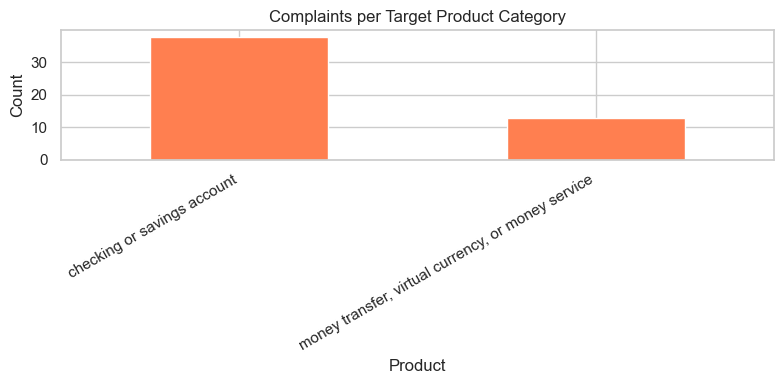

In [75]:
fig, ax = plt.subplots(figsize=(8, 4))
df_filtered['product'].value_counts().plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Complaints per Target Product Category')
ax.set_xlabel('Product')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/filtered_product_dist.png', dpi=120)
plt.show()

## 4. Clean Narratives

In [76]:
# Clean narratives
df_filtered['narrative'] = df_filtered['consumer_complaint_narrative']
df_filtered['clean_narrative'] = df_filtered['narrative'].apply(clean_narrative)
df_filtered['word_count'] = df_filtered['clean_narrative'].str.split().str.len()
df_clean = df_filtered[df_filtered['clean_narrative'].str.len() > 20].copy().reset_index(drop=True)

print(f'After cleaning: {df_clean.shape}')
print('\nWord count stats after cleaning:')
print(df_clean['word_count'].describe())

After cleaning: (51, 21)

Word count stats after cleaning:
count     51.000000
mean     210.215686
std      106.935927
min       56.000000
25%      121.000000
50%      185.000000
75%      269.000000
max      476.000000
Name: word_count, dtype: float64


In [78]:
# Spot-check a few cleaned narratives
for _, row in df_clean.sample(3, random_state=1).iterrows():
    print(f"--- {row['product']} ---")
    print('ORIGINAL:', row['narrative'][:200])
    print('CLEANED: ', row['clean_narrative'][:200])
    print()

--- checking or savings account ---
ORIGINAL: The account holds over {$100.00} and dialogue took place on multiple days the first week of XX/XX/year>. 

I have a long standing savings account with Citibank that I have not made any withdrawals or 
CLEANED:  the account holds over 100.00 and dialogue took place on multiple days the first week of year . i have a long standing savings account with citibank that i have not made any withdrawals or deposits to

--- checking or savings account ---
ORIGINAL: I am in the process of applying for a mortgage, and a recent overdraft fee is preventing my prequalification. I respectfully requested a one-time courtesy refund at my branch and by phone, but was den
CLEANED:  i am in the process of applying for a mortgage, and a recent overdraft fee is preventing my prequalification. i respectfully requested a one-time courtesy refund at my branch and by phone, but was den

--- money transfer, virtual currency, or money service ---
ORIGINAL: My phone was 

## 5. Save Processed Dataset

In [79]:
OUTPUT_PATH = '../data/processed/filtered_complaints.csv'
df_clean.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(df_clean):,} records to {OUTPUT_PATH}')

Saved 51 records to ../data/processed/filtered_complaints.csv


## Key Findings

